In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

con = sqlite3.connect('C:\\Users\\ctabd\\OneDrive\\Desktop\\3rd Sem ojt\\project_3.1\\2_IPL_Cricket\\ipl.db')

def q(sql):
    return pd.read_sql_query(sql, con)

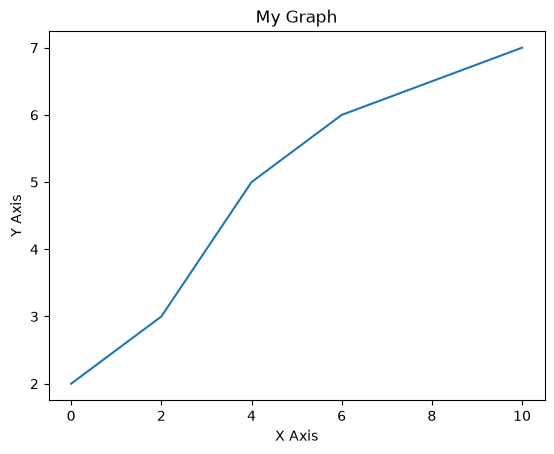

In [7]:
X = [ 0 , 2 , 4 , 6 , 10 ]
Y = [2 , 3 , 5 , 6 , 7 ]
plt.plot(X,Y)
plt.title("My Graph")
plt.xlabel("X Axis")
plt.ylabel("Y Axis")
plt.show()

<Axes: title={'center': 'Total balls in each phases'}, xlabel='diffrent phases og innings', ylabel='total number of balls'>

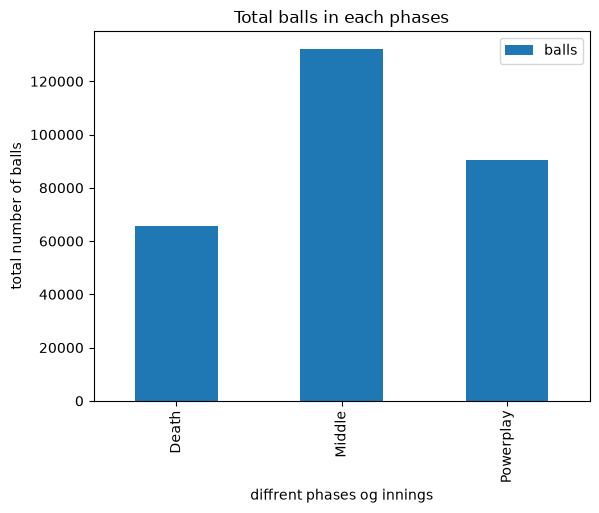

In [9]:
df = pd.read_sql("""select phase, count(*) as balls from v_ball group by phase;""",con)
df.plot(kind="bar",
        x="phase",
        y="balls",
        title="Total balls in each phases",
        xlabel="diffrent phases og innings",
        ylabel="total number of balls")


<Axes: title={'center': 'strike rate of every batter in the death overs'}, xlabel='Batters', ylabel='strike_rate'>

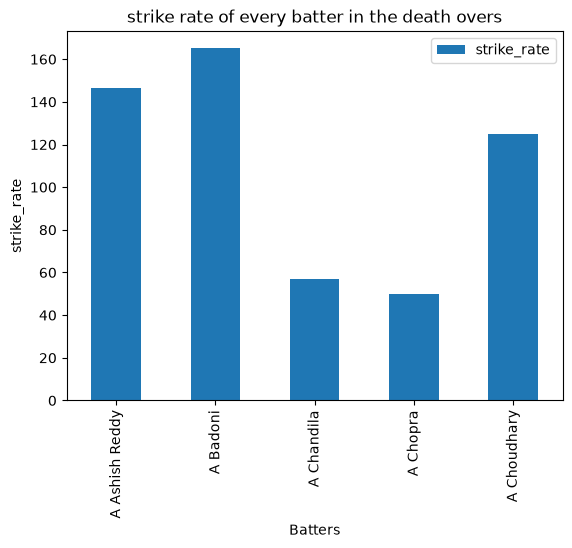

In [13]:
df = pd.read_sql("""SELECT
    batter,
    ROUND(
        100.0 * SUM(batter_runs) /
        SUM(
            CASE
                WHEN is_wide_ball = 0
                 AND is_no_ball = 0
                THEN 1
                ELSE 0
            END
        ),
        2
    ) AS strike_rate
FROM deliveries
WHERE over_number >= 15
  AND is_super_over = 0
GROUP BY batter
limit 5;""",con)


df.plot(kind="bar",
        x="batter",
        y="strike_rate",
        title="strike rate of every batter in the death overs",
        xlabel="Batters",
        ylabel="strike_rate")


<Axes: title={'center': 'players with highest sixes scored in ipl history top 10'}, xlabel='players', ylabel='total sixes'>

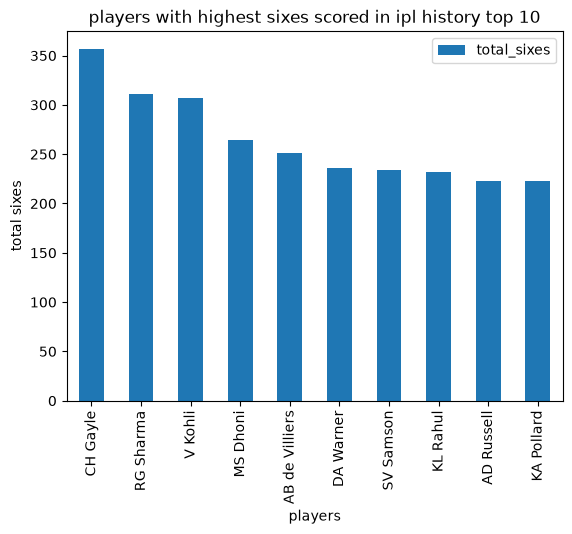

In [16]:
df = pd.read_sql ("""select batter as player,
sum(case when batter_runs = 6 then 1 else 0 end) as total_sixes
from v_ball
group by batter
order by total_sixes desc
limit 10;""",con)


df.plot(kind="bar",
        x="player",
        y="total_sixes",
        title="players with highest sixes scored in ipl history top 10",
        xlabel="players",
        ylabel="total sixes")


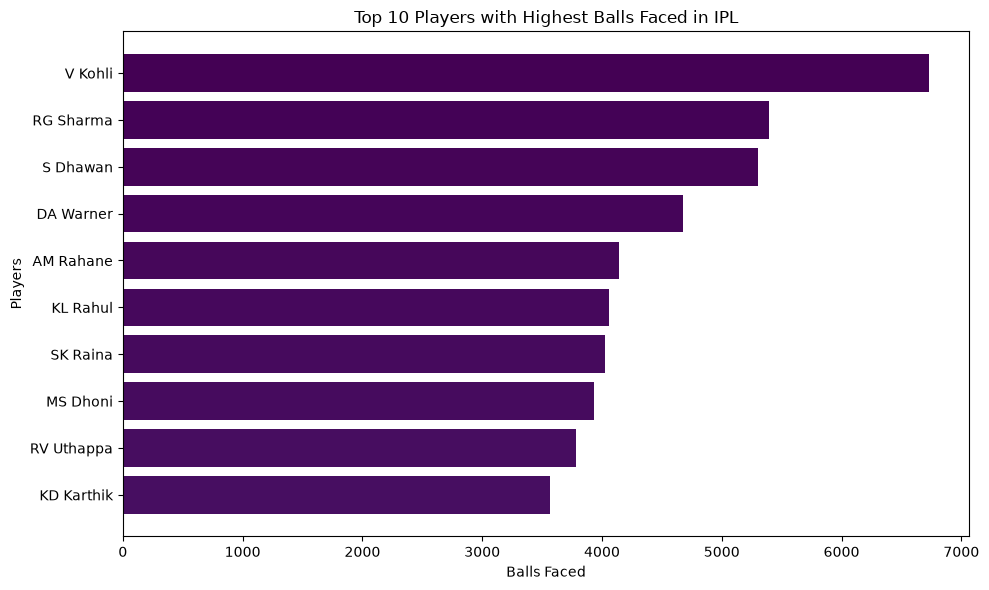

In [18]:
import matplotlib.pyplot as plt

df = pd.read_sql("""
SELECT batter AS player,
       SUM(is_legal) AS balls,
       SUM(batter_runs) AS runs,
       ROUND(100.0 * SUM(batter_runs) / SUM(is_legal), 2) AS strike_rate
FROM v_ball
GROUP BY batter
ORDER BY balls DESC
LIMIT 10;
""", con)

plt.figure(figsize=(10, 6))

plt.barh(
    df["player"],
    df["balls"],
    color=plt.cm.viridis(range(len(df)))
)

plt.xlabel("Balls Faced")
plt.ylabel("Players")
plt.title("Top 10 Players with Highest Balls Faced in IPL")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

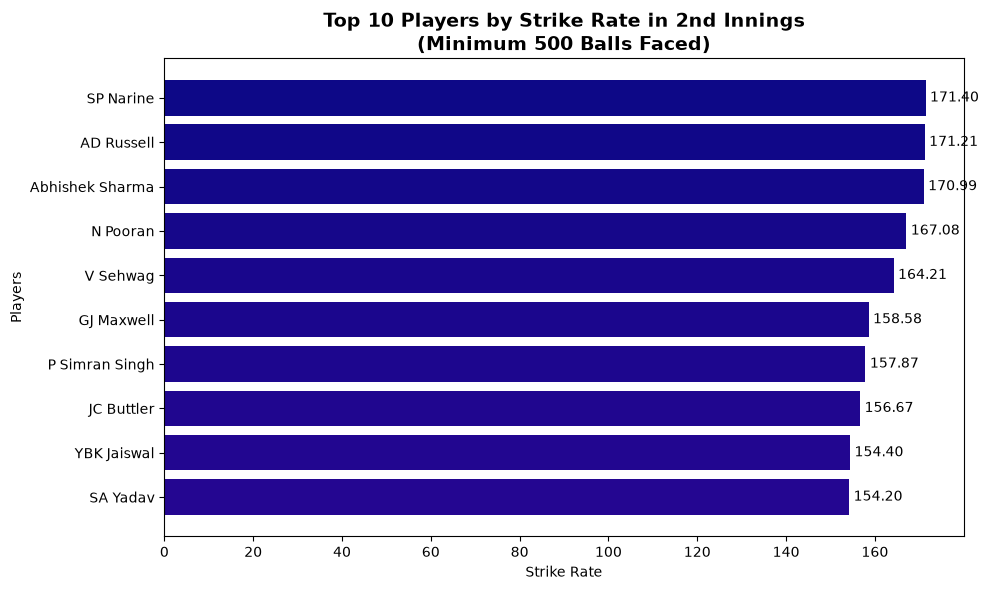

In [19]:
import matplotlib.pyplot as plt

df = pd.read_sql("""
SELECT 
    batter AS player,
    SUM(batter_runs) AS runs,
    SUM(CASE WHEN is_legal = 1 THEN 1 ELSE 0 END) AS balls,
    ROUND(
        100.0 * SUM(batter_runs) /
        SUM(CASE WHEN is_legal = 1 THEN 1 ELSE 0 END),
        2
    ) AS strike_rate
FROM v_ball
WHERE innings = 2
GROUP BY batter
HAVING balls > 500
ORDER BY strike_rate DESC
LIMIT 10;
""", con)


plt.figure(figsize=(10, 6))

bars = plt.barh(
    df["player"],
    df["strike_rate"],
    color=plt.cm.plasma(range(len(df)))
)

plt.xlabel("Strike Rate")
plt.ylabel("Players")
plt.title(
    "Top 10 Players by Strike Rate in 2nd Innings\n(Minimum 500 Balls Faced)",
    fontsize=14,
    fontweight="bold"
)

plt.gca().invert_yaxis()

# Show strike rate values
for bar in bars:
    plt.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.2f}",
        va="center"
    )

plt.tight_layout()
plt.show()

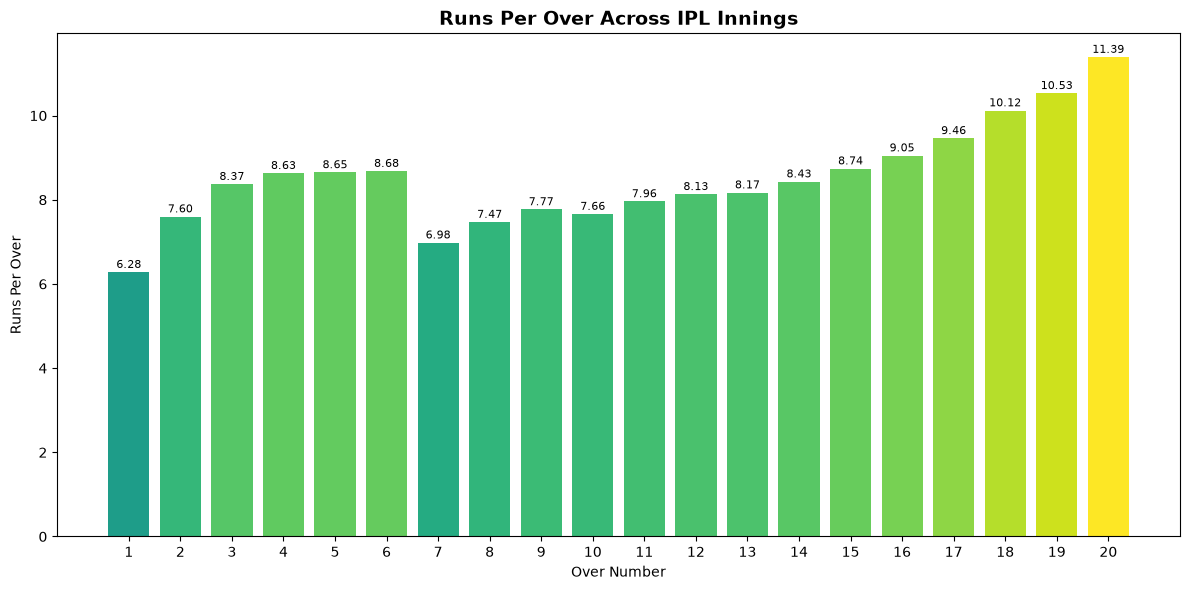

In [20]:
import matplotlib.pyplot as plt

df = pd.read_sql("""
SELECT 
    over_number + 1 AS overs,
    ROUND(6.0 * SUM(total_runs) / SUM(is_legal), 2) AS runs_per_over
FROM v_ball
GROUP BY over_number
ORDER BY runs_per_over DESC;
""", con)

# Sort by over number for proper sequence
df = df.sort_values("overs")

plt.figure(figsize=(12, 6))

bars = plt.bar(
    df["overs"],
    df["runs_per_over"],
    color=plt.cm.viridis(df["runs_per_over"] / df["runs_per_over"].max())
)

plt.xlabel("Over Number")
plt.ylabel("Runs Per Over")
plt.title(
    "Runs Per Over Across IPL Innings",
    fontsize=14,
    fontweight="bold"
)

# Show values on bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{bar.get_height():.2f}",
        ha="center",
        fontsize=8
    )

plt.xticks(df["overs"])
plt.tight_layout()
plt.show()

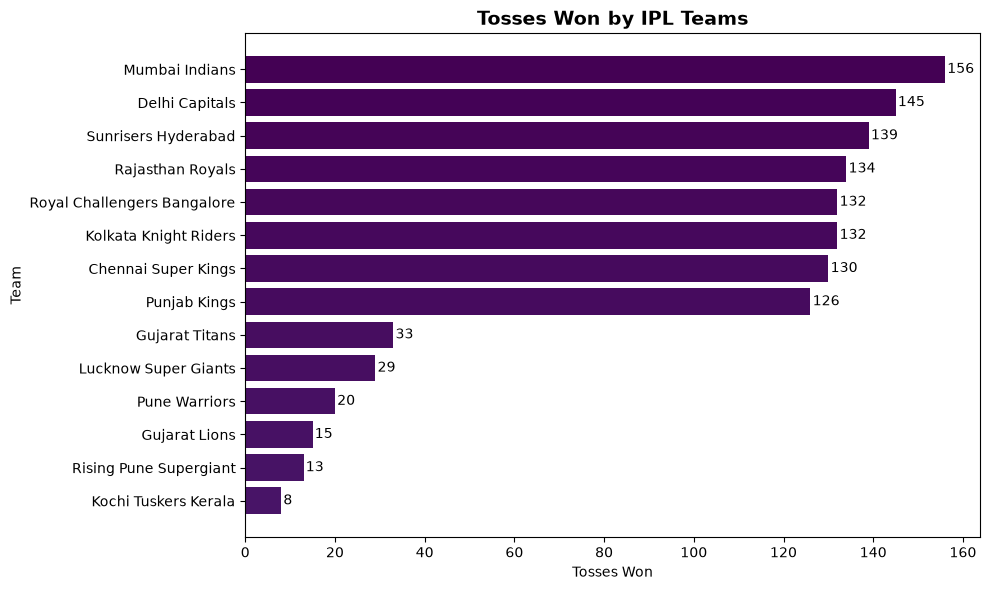

In [21]:
import matplotlib.pyplot as plt

df = pd.read_sql("""
SELECT
    toss_winner,
    COUNT(*) AS toss_won
FROM matches_clean
GROUP BY toss_winner
ORDER BY toss_won DESC;
""", con)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    df["toss_winner"],
    df["toss_won"],
    color=plt.cm.viridis(range(len(df)))
)

plt.xlabel("Tosses Won")
plt.ylabel("Team")
plt.title(
    "Tosses Won by IPL Teams",
    fontsize=14,
    fontweight="bold"
)

# Highest team at the top
plt.gca().invert_yaxis()

# Display values
for bar in bars:
    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        int(bar.get_width()),
        va="center"
    )

plt.tight_layout()
plt.show()

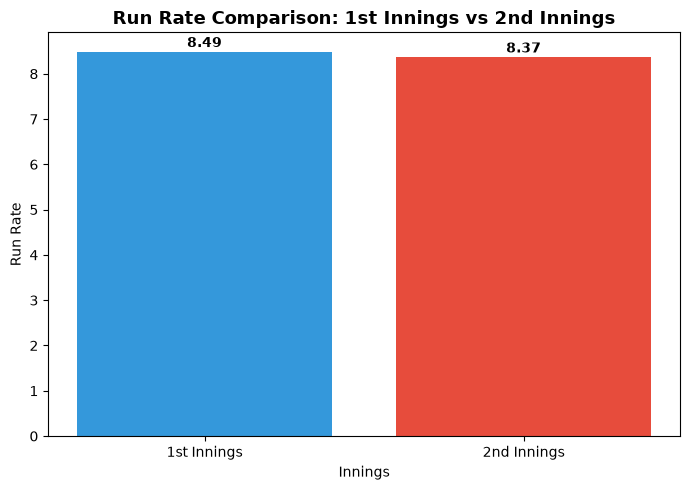

In [22]:
import matplotlib.pyplot as plt

df = pd.read_sql("""
SELECT
    innings,
    ROUND(6.0 * SUM(total_runs) / SUM(is_legal), 2) AS run_rate
FROM v_ball
WHERE innings IN (1, 2)
GROUP BY innings
ORDER BY innings;
""", con)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    ["1st Innings", "2nd Innings"],
    df["run_rate"],
    color=["#3498db", "#e74c3c"]
)

plt.xlabel("Innings")
plt.ylabel("Run Rate")
plt.title(
    "Run Rate Comparison: 1st Innings vs 2nd Innings",
    fontsize=13,
    fontweight="bold"
)

# Show values
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{bar.get_height():.2f}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

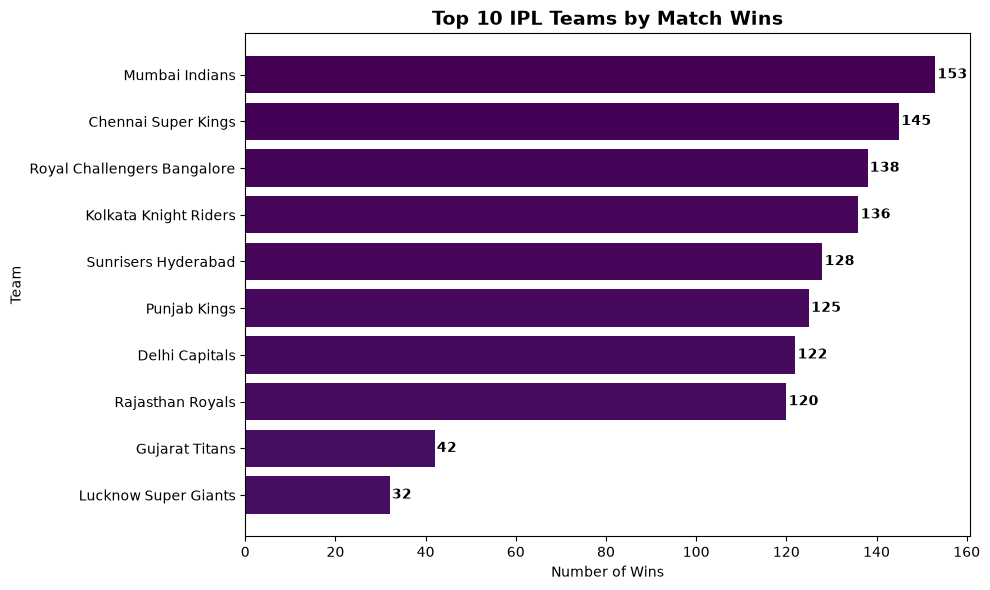

In [23]:
import matplotlib.pyplot as plt

df = pd.read_sql("""
SELECT
    match_winner AS team,
    COUNT(*) AS wins
FROM matches_clean
WHERE RESULT = 'win'
GROUP BY match_winner
ORDER BY wins DESC
LIMIT 10;
""", con)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    df["team"],
    df["wins"],
    color=plt.cm.viridis(range(len(df)))
)

plt.xlabel("Number of Wins")
plt.ylabel("Team")
plt.title(
    "Top 10 IPL Teams by Match Wins",
    fontsize=14,
    fontweight="bold"
)

# Highest wins at the top
plt.gca().invert_yaxis()

# Display values
for bar in bars:
    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        int(bar.get_width()),
        va="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()